In [1]:
import pandas as pd

add chart title and axis labels to increase understanding

In [2]:
transactions = pd.read_csv("../retailFiles/transactions.csv")
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


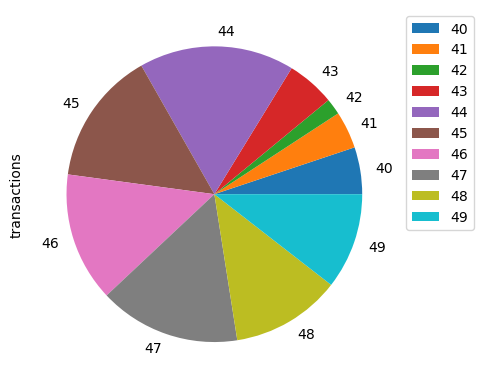

In [ ]:
store_40s = list(range(40, 50))
(transactions
    .query("store_nbr in @store_40s and date.astype('datetime64[ns]').dt.month in [1, 2, 3]")
    .groupby("store_nbr")
    .agg({"transactions": "sum"})
    .plot.pie(y="transactions")
).legend(bbox_to_anchor=(1, 1))

<Axes: xlabel='44', ylabel='47'>

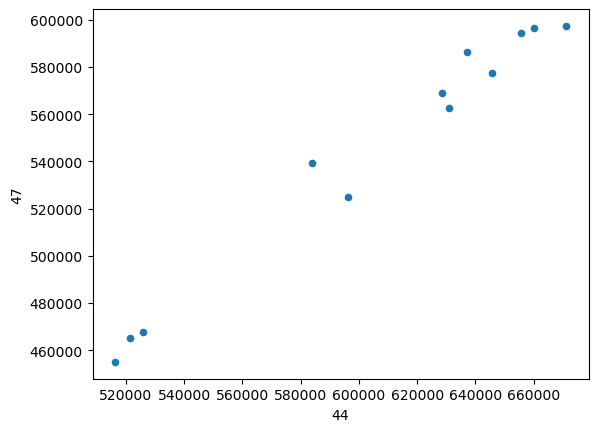

In [17]:
(
    transactions
    .query("store_nbr in @store_40s")
    .pivot_table(
                index=transactions["date"].astype("datetime64[ns]").dt.month,
                columns="store_nbr",
                values="transactions",
                aggfunc="sum"
                )
    .plot.scatter(x=44, y=47)
)

In [22]:
tempTable = (
    transactions
    .query("store_nbr in @store_40s")
    .pivot_table(
                index=transactions["date"].astype("datetime64[ns]"),
                columns="store_nbr",
                values="transactions",
                aggfunc="sum"
                )
)
tempTable

store_nbr,40,41,42,43,44,45,46,47,48,49
date,,,,,,,,,,
2013-01-02,1178.0,915.0,NaN,1385.0,4821.0,4208.0,4886.0,4161.0,3397.0,2346.0
2013-01-03,1171.0,809.0,NaN,1334.0,3618.0,3314.0,3438.0,3660.0,2887.0,1702.0
2013-01-04,1044.0,835.0,NaN,1358.0,4169.0,3630.0,3434.0,3915.0,2900.0,2016.0
2013-01-05,1118.0,1021.0,NaN,1205.0,4921.0,4331.0,4935.0,4764.0,4084.0,2562.0
2013-01-06,1023.0,1142.0,NaN,1194.0,4925.0,4418.0,5401.0,4935.0,4591.0,2795.0
...,...,...,...,...,...,...,...,...,...,...
2017-08-11,1090.0,1316.0,1055.0,1532.0,4418.0,4302.0,3814.0,4009.0,3220.0,3117.0
2017-08-12,1324.0,1254.0,1019.0,1540.0,4277.0,3994.0,3697.0,3825.0,3198.0,2985.0
2017-08-13,1095.0,1346.0,932.0,1700.0,4392.0,4054.0,3839.0,3741.0,3381.0,3028.0


<Axes: xlabel='44', ylabel='47'>

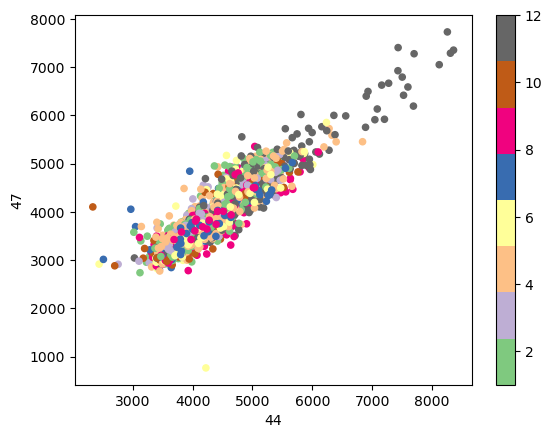

In [ ]:
tempTable.plot.scatter(x=44, 
                       y=47,
                       c=tempTable.index.month,
                       cmap="Accent")